# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [ ]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

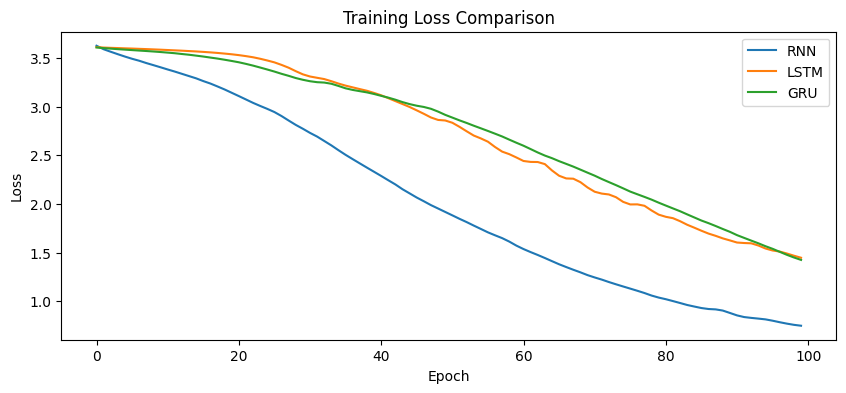

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [ ]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models transforming artificial intelligence sentences


LSTM: deep learning models can generate meaningful sentences


GRU : deep learning is faster and simpler than


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

In [ ]:
# Custom paragraph corpus for student tasks
student_corpus = """
deep learning is a subset of machine learning that uses multi layered artificial neural networks to learn representations from data.
recurrent neural networks are a class of neural networks designed to process sequential data and recognize patterns over time.
these networks maintain a form of memory by passing information across sequence steps to remember previous inputs.
long short term memory networks are advanced recurrent models that handle long term dependencies using gating mechanisms.
gated recurrent units are optimized models that simplify the architecture of lstms while maintaining similar performance.
text generation models learn to predict the next word in a sequence to construct coherent sentences.
"""

import re
# Clean the corpus by lowercasing and removing punctuation
student_cleaned = student_corpus.lower()
student_cleaned = re.sub(r'[^\w\s\n]', '', student_cleaned)
student_cleaned = re.sub(r' +', ' ', student_cleaned)

# Initialize tokenizer for student tasks
student_tokenizer = Tokenizer()
student_tokenizer.fit_on_texts([student_cleaned])

student_total_words = len(student_tokenizer.word_index) + 1
print("Student task vocabulary size:", student_total_words)

student_sequences = []
for line in student_cleaned.split('\n'):
    line = line.strip()
    if not line:
        continue
    token_list = student_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        student_sequences.append(n_gram_seq)

student_max_len = max(len(seq) for seq in student_sequences)
student_sequences = pad_sequences(student_sequences, maxlen=student_max_len, padding='pre')

X_student = student_sequences[:, :-1]
y_student = student_sequences[:, -1]

print("Student X shape:", X_student.shape)
print("Student y shape:", y_student.shape)

Student task vocabulary size: 74
Student X shape: (99, 19)
Student y shape: (99,)


In [ ]:
# Train SimpleRNN with 128 hidden units and 64 embedding dimensions for 200 epochs
student_rnn = Sequential([
    Embedding(student_total_words, 64, input_length=student_max_len-1),
    SimpleRNN(128),
    Dense(student_total_words, activation='softmax')
])

student_rnn.compile(loss='sparse_categorical_crossentropy',
                    optimizer='adam',
                    metrics=['accuracy'])

print("Training student SimpleRNN model for 200 epochs...")
student_rnn_history = student_rnn.fit(X_student, y_student, epochs=200, verbose=0)
print("Student SimpleRNN training completed")

Training student SimpleRNN model for 200 epochs...


Student SimpleRNN training completed


In [ ]:
# Train LSTM with 128 hidden units and 64 embedding dimensions for 200 epochs
student_lstm = Sequential([
    Embedding(student_total_words, 64, input_length=student_max_len-1),
    LSTM(128),
    Dense(student_total_words, activation='softmax')
])

student_lstm.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

print("Training student LSTM model for 200 epochs...")
student_lstm_history = student_lstm.fit(X_student, y_student, epochs=200, verbose=0)
print("Student LSTM training completed")

Training student LSTM model for 200 epochs...


Student LSTM training completed


In [ ]:
# Train GRU with 128 hidden units and 64 embedding dimensions for 200 epochs
student_gru = Sequential([
    Embedding(student_total_words, 64, input_length=student_max_len-1),
    GRU(128),
    Dense(student_total_words, activation='softmax')
])

student_gru.compile(loss='sparse_categorical_crossentropy',
                    optimizer='adam',
                    metrics=['accuracy'])

print("Training student GRU model for 200 epochs...")
student_gru_history = student_gru.fit(X_student, y_student, epochs=200, verbose=0)
print("Student GRU training completed")

Training student GRU model for 200 epochs...


Student GRU training completed


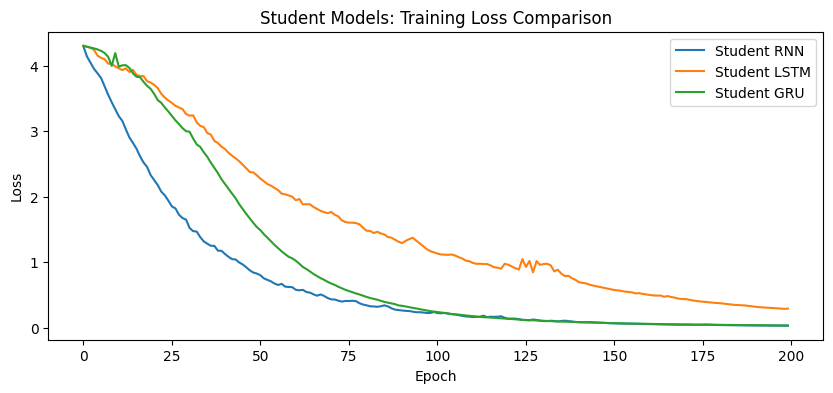

In [ ]:
# Map optimization trajectories for student models on a line plot
plt.figure(figsize=(10, 4))
plt.plot(student_rnn_history.history['loss'], label='Student RNN')
plt.plot(student_lstm_history.history['loss'], label='Student LSTM')
plt.plot(student_gru_history.history['loss'], label='Student GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Student Models: Training Loss Comparison")
plt.legend()
plt.show()

In [ ]:
# Function to generate text using the student models and tokenizer
def generate_student_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = student_tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=student_max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in student_tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

# Generate 10 words using the student models
print("RNN (Student) :", generate_student_text(student_rnn, "deep learning", 10))
print("LSTM (Student):", generate_student_text(student_lstm, "deep learning", 10))
print("GRU (Student) :", generate_student_text(student_gru, "deep learning", 10))

RNN (Student) : deep learning is a subset of machine learning that uses multi layered


LSTM (Student): deep learning is a subset of machine learning that uses multi layered


GRU (Student) : deep learning is a subset of machine learning that uses multi layered


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**